In [ ]:
## Import necessary libraries
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Reason of choosing SP500, NASDAQ, Crude Oil and Gold
The analysis includes a mix of market indices and commodities to capture how different segments of the global financial system respond to geopolitical stress.

S&P 500 serves as the baseline for the overall health of the US economy. It reflects broad economic sentiment and allows us to evaluate how large-cap companies respond to geopolitical uncertainty such as the US–Iran conflict.

NASDAQ represents technology and growth-oriented companies. These firms are typically more sensitive to uncertainty and interest rate changes, making this index useful for analyzing how high-growth sectors react during periods of conflict.

Crude_Oil is the most important global commodity due to its role in energy supply and economic activity. With the blockade of Strait of Hormuz, there has been panic related to crude oil throughout the world, as Strait of Hormuz is the global oil choke point which makes crude oil direct impact variable of this war.

Gold is a traditional safe haven assets. During periods of uncertainity, investors move their capital into gold to preserve value. Analyzing gold prices help assess the degree of risk aversion.

In [ ]:
## This dictionary contains major market indices and stocks.
tickers = {
"SP500": "^GSPC",
"NASDAQ": "^IXIC",
"Crude_Oil": "CL=F",
"Gold": "GC=F"
}

In [ ]:
## Downloaded the data from January 1st, 2026 to April 30th, 2026.
raw_data = yf.download(list(tickers.values()), start="2026-01-01", end="2026-04-30")
## Reversed the Key and Value pairs.
data = raw_data["Close"].rename(columns={v: k for k, v in tickers.items()})



[*********************100%***********************]  4 of 4 completed

Ticker      Crude_Oil         Gold        SP500        NASDAQ
Date                                                         
2026-01-02  57.320000  4314.399902  6858.470215  23235.630859
2026-01-05  58.320000  4436.899902  6902.049805  23395.820312
2026-01-06  57.130001  4482.200195  6944.819824  23547.169922
2026-01-07  55.990002  4449.299805  6920.930176  23584.279297
2026-01-08  57.759998  4449.700195  6921.459961  23480.019531


In [ ]:
## We calculate the returns of all the stocks. Returns are calculated from previous days.
returns = data.pct_change()
## The first row will always be NA. Therefore, we drop NA. 
returns = returns.dropna()


Ticker      Crude_Oil      Gold     SP500    NASDAQ
Date                                               
2026-01-05   0.017446  0.028393  0.006354  0.006894
2026-01-06  -0.020405  0.010210  0.006197  0.006469
2026-01-07  -0.019954 -0.007340 -0.003440  0.001576
2026-01-08   0.031613  0.000090  0.000077 -0.004421
2026-01-09   0.023546  0.009124  0.006475  0.008149


In [ ]:
## Calculating Peak
## We use cummax() to calculate the cumulative maximum of the closing prices, which gives us the peak value at each point in time.
peak = data.cummax()

## Calculate Drawdown
## Drawdown is percentage decline from the peak to the current closing price.
drawdown = (data - peak)/peak


<class 'pandas.DataFrame'>


In [ ]:
## A dictionary of major war events in the US - Iran war.
war_events = {
    "2026-02-28": "Conflict",
    "2026-03-04": "Blockade",
    "2026-04-07": "Ceasefire"
}

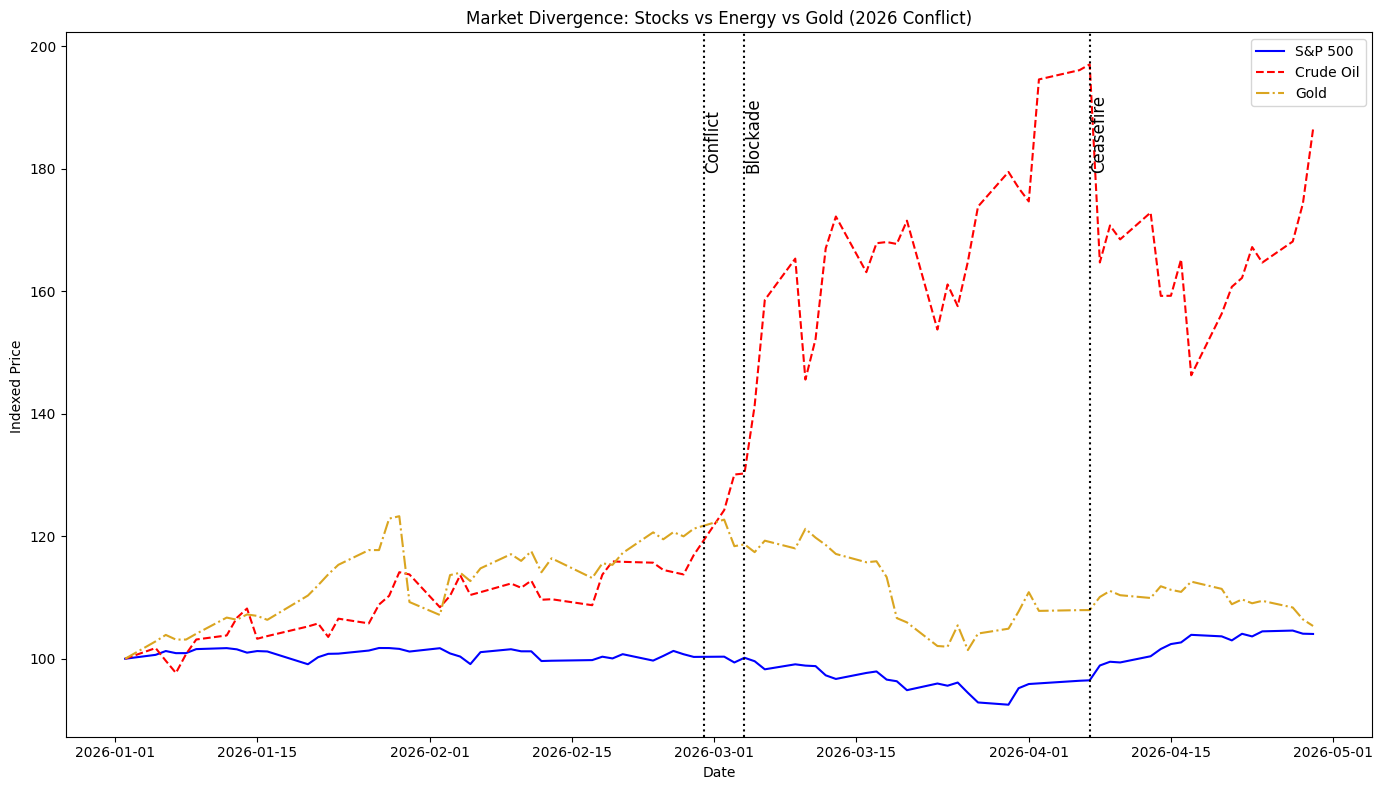

In [ ]:
## # Plot normalized prices to highlight divergence between equities and commodities during geopolital stress.
fig, ax1 = plt.subplots(1,1,figsize=(14,8))
ax1.plot(data.index, data['SP500'] / data['SP500'].iloc[0] * 100, label='S&P 500', color='blue')
ax1.plot(data.index, data['Crude_Oil'] / data['Crude_Oil'].iloc[0] * 100, label='Crude Oil', color='red', linestyle='--')
ax1.plot(data.index, data['Gold'] / data['Gold'].iloc[0] * 100, label='Gold', color='goldenrod', linestyle='-.' )

for d, label in war_events.items():
    ax1.axvline(pd.to_datetime(d), color='black', linestyle=':')
    ax1.text(pd.to_datetime(d), 180, label, rotation=90, fontsize=12)
ax1.set_xlabel("Date")
ax1.set_ylabel("Normalized Price ")
ax1.legend()
ax1.set_title("Market Divergence: Equities vs Energy vs Gold (2026 Conflict)")
plt.tight_layout()
plt.show()



### Insights on the Market Divergence Graph
1. Crude oil reacted strongly throughout the analyzed conflict period, showing how quickly markets respond to geopolitical uncertainty. Prices were already rising before the conflict, but they rose sharply once tensions escalated and the risk of supply disruption increased around the Strait of Hormuz. 
The jump in oil prices between Conflict and Blockade suggested that the traders predicted the supply chain disruptions. After the blockade, it surged steeply until the ceasefire was announced, as fears of restricted supply pushed prices up. After the ceasefire, the crude oil dipped significantly as immediate fears eased and traders began selling.
However, prices did not return to pre-conflict levels immediately ndicating uncertainity and reduced confidence. Now, prices started climbing again due to stalled diplomatic negotiations and continued blockade. 
Overall, this pattern demonstrates how sensitive global commodities like oil are to geopolitical events,especially when the conflict involves key suppliers in the global energy market.

2. S&P 500 index decoupled from the oil during the time of conflict. While the S&P 500 dropped slightly, oil was soaring. The S&P 500 index remained stable, supported by sectoral diversification and mixed performance across energy, defensive, and growth components.

3. When oil prices spiked about 70%, it created a massive shock on the economy. Companies and hedge funds suddenly become desperate for cash to pay for these rising energy costs, forcing them to liquidate their gold holdings. Gold is considered as a safe haven but in this war situation traders chose liquidity over gold. Therefore, it dropped signifcantly after the blockade. In moments of crises, liquidity matters more than safety.

Moreover, this also shows that how capital tends to rotate rapidly across asset classes depending on stress levels and funding needs.

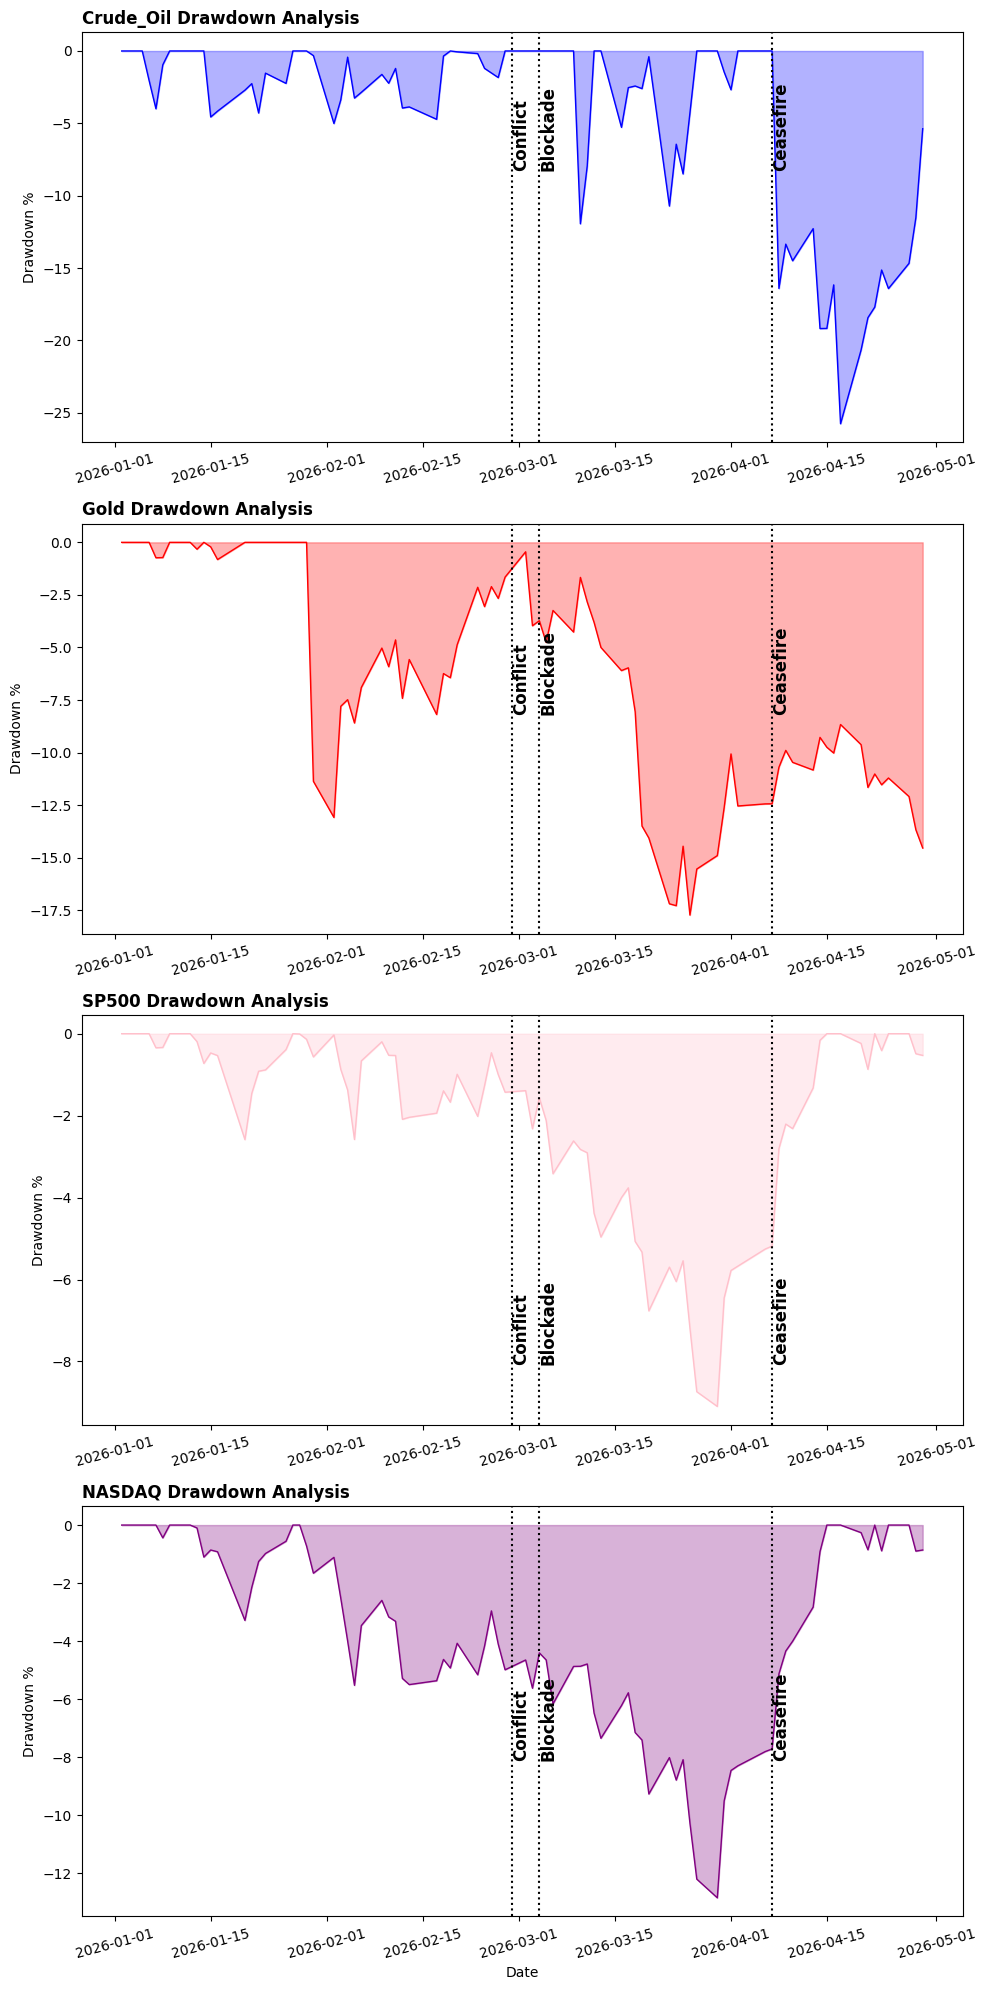

In [ ]:
## Drawdown analysis graph for each index.
fig, axes = plt.subplots(4, 1, figsize=(10, 20))
colors = ['blue', 'red', 'pink', 'purple']
for i,ticker in enumerate(drawdown.columns):
    axes[i].fill_between(drawdown.index,drawdown[ticker] * 100, label=ticker,color =  colors[i],alpha = 0.3)
    axes[i].plot(drawdown.index, drawdown[ticker] * 100, color=colors[i], linewidth=1)
    axes[i].set_title(f"{ticker} Drawdown Analysis", loc='left', fontsize=12, fontweight='bold')
    axes[i].set_ylabel("Drawdown %")
    axes[i].tick_params(axis = 'x',rotation = 15)
    for d, label in war_events.items():
        axes[i].axvline(pd.to_datetime(d), color='black', linestyle=':')
        axes[i].text(pd.to_datetime(d), -8,label, rotation=90, fontsize=12,fontweight = "bold")   

plt.xlabel("Date")
plt.tight_layout()
plt.show()   

### Insights on Drawdown of each index
1. The crude oil drawdown analysis reflects a classic “buy the rumor, sell the fact” pattern. Prices surged during the conflict and blockade, but fell nearly 25% from their peak once peace was signaled. The quick V-shaped recovery, however, indicates that supply concerns remain a key factor.

2. The drawdown analysis of gold shows a deviation from its typical safe-haven behavior.Instead of a brief dip, gold remained in drawdown until the ceasefire was announced, only beginning to recover afterward. Its deepest decline, around 17%, occurred during the blockade phase. However, as crude oil began to recover again due to stalled negotiations, gold weakened once more. This indicates that during periods of heightened geopolitical stress, investors tend to prioritize liquidity, leading to selling traditional safe-haven assets like gold.

3. Both the S&P 500 and NASDAQ Composite dropped as soon as the conflict began, reflecting the negative impact of uncertainty as investors moved toward safer assets. Both rebounded sharply after the ceasefire. Notably, the NASDAQ fell more than the S&P 500, showing that high-growth tech stocks are more sensitive to geopolitical risk. 

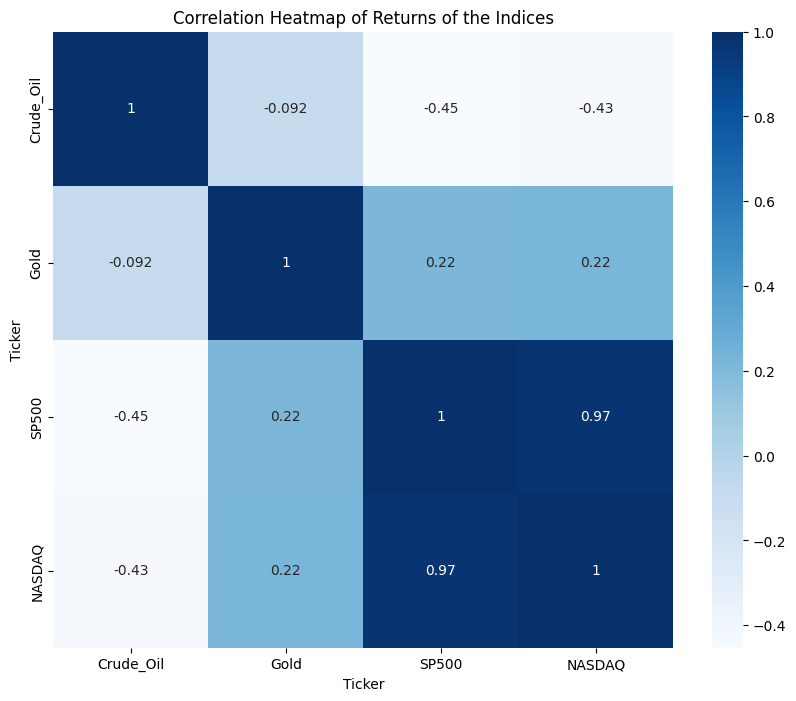

In [ ]:
# Correlation Heatmap
correlation = returns.corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation,annot=True,cmap="Blues")
plt.title("Correlation Heatmap of Returns of the Indices")
plt.show()

### Insights on correlation
1. The crude oil shows negative correlation with both S&P 500 and NASDAQ composite, and a near zero correlation with Gold. This aligns with the divergence seen earlier, where rising oil prices coincided with weakness in the stock market.
2. Gold exhibits a very weak positive correlation with equity indices, suggesting it did not effectively act as a hedge during this period. Ideally, gold is expected to have a negative or low correlation with stocks, but in this case, it did not provide strong downside protection.
3. The S&P 500 and NASDAQ show a strong positive correlation, indicating that they tend to move together even during periods of uncertainty. This implies that holding both offers limited diversification, making a portfolio more exposed to systemic crash.

In [156]:
from datetime import date

## Summary
summary = []

for ticker in data.columns:
    volatility = returns[ticker].std()
    drawdown_value = drawdown[ticker].min()
    drawdown_date = drawdown[ticker].idxmin()
    peak_at_crash = peak[ticker].loc[drawdown_date]
    after_crash = data[ticker].loc[drawdown_date:]
    crash_value = data[ticker].loc[drawdown_date]
    peak_date = peak[ticker].idxmax()
    new_peak = peak[ticker].max()
    current_value = data[ticker].iloc[-1]
    mean_return = returns[ticker].mean()
    # Find the recovery period
    recovery = after_crash[after_crash >= peak_at_crash]
    
    if not recovery.empty:
        recovery_days = (recovery.index.min() - drawdown_date).days
        recovery_date = recovery.index.min()
        recovery_value = recovery.iloc[0]
        print(f"It took {ticker} {recovery_days} days to recover from the worst drawdown. It recovered on {recovery_date.date()}.")
    else:
        recovery_date = None
        recovery_value = None
        print(f"{ticker} has not recovered from the worst drawdown yet. It has been {( pd.Timestamp(date.today()) - drawdown_date).days} days since the drawdown. ")
        


    summary.append([ticker,volatility,drawdown_date.date(),drawdown_value*100,crash_value,peak_at_crash,recovery_date,recovery_value,peak_date,new_peak,current_value,mean_return * 100])

print("\n")
summary_df = pd.DataFrame(summary, columns=["Index", "Volatility", "Drawdown Date", "Worst Drawdown(%)", "Crash Value", "Peak at Crash", "Recovery Date", "Recovery Value","Peak Date", "New Peak","Current Value","Mean Return"])
print(summary_df)   




Crude_Oil has not recovered from the worst drawdown yet. It has been 14 days since the drawdown. 
Gold has not recovered from the worst drawdown yet. It has been 36 days since the drawdown. 
It took SP500 16 days to recover from the worst drawdown. It recovered on 2026-04-15.
It took NASDAQ 16 days to recover from the worst drawdown. It recovered on 2026-04-15.


       Index  Volatility Drawdown Date  Worst Drawdown(%)   Crash Value  \
0  Crude_Oil    0.046310    2026-04-17         -25.763612     83.849998   
1       Gold    0.023816    2026-03-26         -17.729015   4375.500000   
2      SP500    0.009019    2026-03-30          -9.097525   6343.720215   
3     NASDAQ    0.012004    2026-03-30         -12.837955  20794.640625   

   Peak at Crash Recovery Date  Recovery Value  Peak Date      New Peak  \
0     112.949997           NaT             NaN 2026-04-07    112.949997   
1    5318.399902           NaT             NaN 2026-01-29   5318.399902   
2    6978.600098    2026-04-15   

### Insights on summary
1. Both the S&P 500 and NASDAQ Composite moved closely together, showing strong synchronization. They reached their worst drawdown on the same date and recovered within a similar timeframe, suggesting that investors returned to equities quickly once the conflict began to stabilize. This insight also aligns with the correlation heatmap.
2. The slower recovery in Gold supports the earlier observation that gold was being used more as a source of liquidity rather than attracting fresh investment, even as equity markets started to rebound.
3. *** Most Important
Despite experiencing the deepest drawdown and not fully recovering, crude oil remained highly volatile and delivered the strongest gains during the period. This highlights a classic “high risk, high return” dynamic, where greater potential rewards come with increased volatility and downside risk.

In [ ]:
summary_df.to_csv("Market Analysis Conflict 2026.csv",index = False)

In [157]:
data.to_csv("Market Data.csv")


In [158]:
df = pd.read_csv("C:/ProgramData/MySQL/MySQL Server 9.4/Uploads/Market Data.csv")
df_long = df.melt(
    id_vars=["Date"],
    var_name="Ticker",
    value_name="Price"
)

df_long.to_csv("clean_file.csv", index=False)